In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, SVR
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json


In [63]:
# Định nghĩa features (giữ nguyên như bạn chọn, trừ target)
FEATURES = [
    'Year', 'AHS_Weighted_Average_Percent', 'MFN_Weighted_Average_Percent',
    'AHS_Duty_Free_Tariff_Lines_Share_Percent', 'pv_rank', 'va_rank',
    'Tariff_Gap', 'Country_Growth_Percent', 'Effective_Tariff'
]

TARGET_CLASS = 'has_RCA'
TARGET_REG = 'Log_Export'  # Đổi target regression thành Log_Export

Root_path = r'/home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111'

In [64]:
def prepare_data(file_path):
    df = pd.read_csv(file_path)
    

    if 'Country_Name' in df.columns:
        le = LabelEncoder()
        df['Country_Name_encoded'] = le.fit_transform(df['Country_Name'])
        if 'Country_Name_encoded' not in FEATURES:
            FEATURES.append('Country_Name_encoded')
    
    train = df[df['Year'] <= 2015].copy()
    test = df[df['Year'] > 2015].copy()
    
    if test.shape[0] == 0:
        stratify_col = None
        if TARGET_CLASS in df.columns and df[TARGET_CLASS].nunique() > 1:
            stratify_col = df[TARGET_CLASS]
        train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=stratify_col)
        train = train.copy()
        test = test.copy()
    
    X_train = train[FEATURES]
    X_test = test[FEATURES]
    
    numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
    scaler = RobustScaler()
    if len(numeric_cols) > 0:
        X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
    
    y_class_train = train[TARGET_CLASS] if TARGET_CLASS in train.columns else pd.Series(dtype=int)
    y_reg_train = train[TARGET_REG] if TARGET_REG in train.columns else pd.Series(dtype=float)
    y_class_test = test[TARGET_CLASS] if TARGET_CLASS in test.columns else pd.Series(dtype=int)
    y_reg_test = test[TARGET_REG] if TARGET_REG in test.columns else pd.Series(dtype=float)
    
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    return X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test


## RCA classification

In [65]:
def train_class_models(X_train, X_test, y_train, y_test):
    models = {
        'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Naive Bayes': GaussianNB()
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = {'Accuracy': acc, 'F1': f1}
        print(f"{name} - Accuracy: {acc:.4f}, F1: {f1:.4f}")
        print(classification_report(y_test, y_pred))
        
        if name == 'Random Forest':
            importances = pd.Series(model.feature_importances_, index=X_train.columns)
            importances.sort_values(ascending=False).plot(kind='barh')
            plt.title('Feature Importance - RF Classifier (has_RCA)')
            plt.show()
    
    return results


In [66]:
def train_reg_models(X_train, X_test, y_train, y_test):
    models = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1),
        'Decision Tree Reg': DecisionTreeRegressor(random_state=42),
        'Random Forest Reg': RandomForestRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'MSE': mse, 'R2': r2}
        print(f"{name} - MSE: {mse:.4f}, R2: {r2:.4f}")
        
        if name == 'Random Forest Reg':
            importances = pd.Series(model.feature_importances_, index=X_train.columns)
            importances.sort_values(ascending=False).plot(kind='barh')
            plt.title('Feature Importance - RF Regressor (Log_Export)')
            plt.show()
    
    return results

In [67]:

file_path = Root_path + r'/Data/Gold/Gold_1.csv'
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = prepare_data(file_path)

Train size: 4047, Test size: 1453


/tmp/ipykernel_125617/1577807537.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
/tmp/ipykernel_125617/1577807537.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


SVM - Accuracy: 0.7302, F1: 0.8128
              precision    recall  f1-score   support

           0       0.46      0.59      0.52       353
           1       0.86      0.77      0.81      1100

    accuracy                           0.73      1453
   macro avg       0.66      0.68      0.67      1453
weighted avg       0.76      0.73      0.74      1453

Random Forest - Accuracy: 0.8396, F1: 0.9013
              precision    recall  f1-score   support

           0       0.81      0.44      0.57       353
           1       0.84      0.97      0.90      1100

    accuracy                           0.84      1453
   macro avg       0.83      0.70      0.74      1453
weighted avg       0.84      0.84      0.82      1453



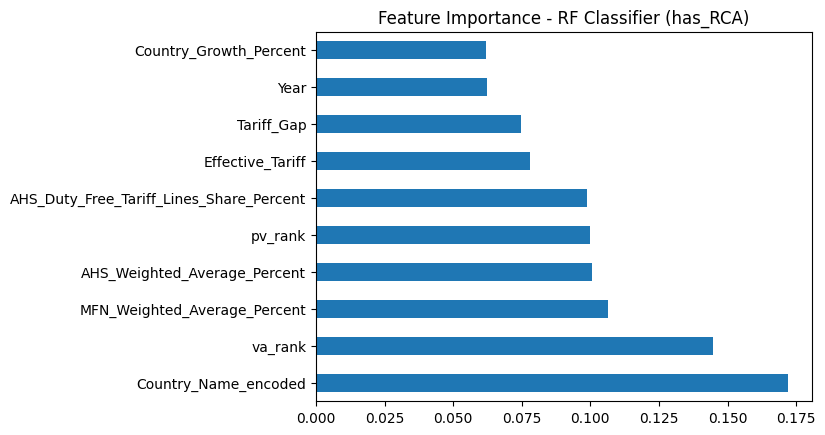

KNN - Accuracy: 0.7805, F1: 0.8635
              precision    recall  f1-score   support

           0       0.58      0.35      0.44       353
           1       0.82      0.92      0.86      1100

    accuracy                           0.78      1453
   macro avg       0.70      0.64      0.65      1453
weighted avg       0.76      0.78      0.76      1453

Decision Tree - Accuracy: 0.8190, F1: 0.8831
              precision    recall  f1-score   support

           0       0.65      0.56      0.60       353
           1       0.86      0.90      0.88      1100

    accuracy                           0.82      1453
   macro avg       0.76      0.73      0.74      1453
weighted avg       0.81      0.82      0.81      1453

Naive Bayes - Accuracy: 0.7460, F1: 0.8430
              precision    recall  f1-score   support

           0       0.46      0.26      0.34       353
           1       0.79      0.90      0.84      1100

    accuracy                           0.75      1453
   ma

In [68]:
class_results = train_class_models(X_train, X_test, y_class_train, y_class_test)

Ridge - MSE: 6.2791, R2: 0.0830
Lasso - MSE: 5.9996, R2: 0.1238
Decision Tree Reg - MSE: 4.9835, R2: 0.2722
Random Forest Reg - MSE: 2.8158, R2: 0.5888


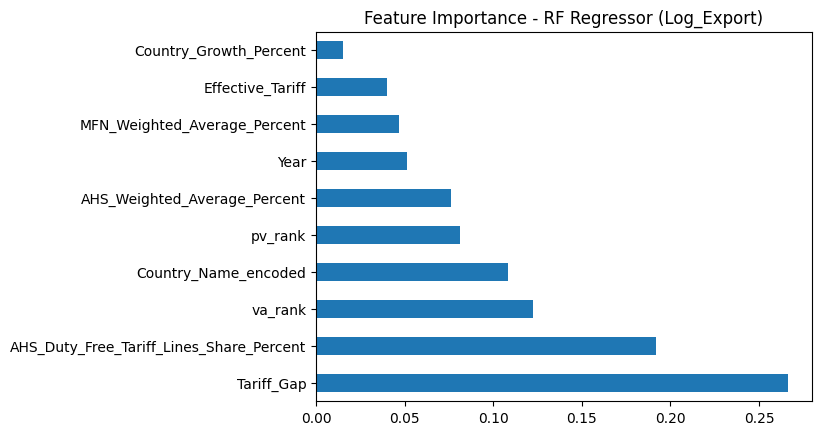

In [69]:
reg_results = train_reg_models(X_train, X_test, y_reg_train, y_reg_test)

In [70]:
os.makedirs(Root_path + '/models/results', exist_ok=True)
pd.DataFrame(class_results).to_csv(Root_path + '/models/results/classification_results.csv')
pd.DataFrame(reg_results).to_csv(Root_path + '/models/results/regression_results.csv')

In [73]:
os.makedirs(Root_path + '/models/classification', exist_ok=True)
os.makedirs(Root_path + '/models/regression', exist_ok=True)
model_dir = Root_path + '/models'

clf_models = {
    'svm_clf': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'rf_clf': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'knn_clf': KNeighborsClassifier(n_neighbors=5),
    'dt_clf': DecisionTreeClassifier(random_state=42),
    'nb_clf': GaussianNB()
}

for name, model in clf_models.items():
    model.fit(X_train, y_class_train)
    joblib.dump(model, os.path.join(model_dir, f"classification/{name}.joblib"))

reg_models = {
    'ridge_reg': Ridge(alpha=1.0),
    'lasso_reg': Lasso(alpha=0.1),
    'dt_reg': DecisionTreeRegressor(random_state=42),
    'rf_reg': RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in reg_models.items():
    model.fit(X_train, y_reg_train)
    joblib.dump(model, os.path.join(model_dir, f"regression/{name}.joblib"))

meta = {'FEATURES': FEATURES, 'TARGET_CLASS': TARGET_CLASS, 'TARGET_REG': TARGET_REG}
with open(os.path.join(model_dir, 'metadata.json'), 'w') as f:
    json.dump(meta, f)

print(f"Saved {len(clf_models)+len(reg_models)} models and metadata to: {model_dir}")

Saved 9 models and metadata to: /home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111/models
